In [1]:
from mri_dataloader import MRI_Dataloader, Patient

In [2]:
md = MRI_Dataloader()

In [6]:
patient = Patient("YG_ZZPMMPUF7RF3")
patient.merge_lesion_to_trajectory()

Extracting lesion data from 8 scans...
  Scan 0 (2011-07-27): 2 lesions
  Scan 1 (2011-09-07): 1 lesions
  Scan 2 (2011-10-19): 1 lesions
  Scan 3 (2012-01-09): 2 lesions
  Scan 4 (2012-03-05): 1 lesions
  Scan 5 (2012-07-26): 1 lesions
  Scan 6 (2015-05-09): 17 lesions
  Scan 7 (2015-06-10): 13 lesions

Lesion counts per scan: [2, 1, 1, 2, 1, 1, 17, 13]

Matching lesions between consecutive scans...
    Scan 0->1: distance matrix (min/max): 15.21/254.95
      MATCH: lesion 1->0, dist=15.2px, size_ratio=1.08x
      -> 1 matches found

  Scan 0 -> 1: 1/2 matches (1 unmatched from previous)
    Scan 1->2: distance matrix (min/max): 16.79/16.79
      MATCH: lesion 0->0, dist=16.8px, size_ratio=1.16x
      -> 1 matches found

  Scan 1 -> 2: 1/1 matches (0 unmatched from previous)
    Scan 2->3: distance matrix (min/max): 6.67/156.88
      MATCH: lesion 0->1, dist=6.7px, size_ratio=0.76x
      -> 1 matches found

  Scan 2 -> 3: 1/1 matches (0 unmatched from previous)
  Scan 3 -> 4: 1/2 matc

In [10]:
md.find_lesion_trajectory('YG_4T5BPNBJS1ZN', 1).plot_animation()

In [9]:
for i in range(15):
    try:
        md.find_lesion_trajectory('YG_NRSFSRTTONBY', i).plot_animation()
    except Exception as e:
        print(f"Error occurred for scan {i}: {e}")

Lesion trajectory file not found at data/entire_yale_dataset/predictions/YG_NRSFSRTTONBY/lesion_trajectories_0.npz. Cannot load trajectory.
Error occurred for scan 0: 'NoneType' object has no attribute 'plot_animation'
Error occurred for scan 2: division by zero
Error occurred for scan 4: division by zero
Error occurred for scan 5: division by zero
Error occurred for scan 6: division by zero
Error occurred for scan 7: division by zero
Error occurred for scan 10: division by zero
Error occurred for scan 11: division by zero
Error occurred for scan 13: division by zero
Error occurred for scan 14: division by zero


In [16]:
md.find_lesion_trajectory('YG_NRSFSRTTONBY', 15).plot_animation()

ZeroDivisionError: division by zero

In [19]:
patient.plot_registered_3d_lesion_position()

TypeError: unsupported operand type(s) for -: 'list' and 'float'

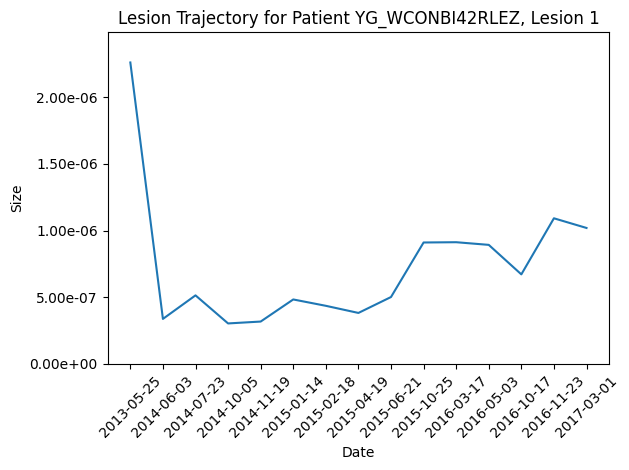

In [4]:
mri_dataloader = MRI_Dataloader()
trj = mri_dataloader.find_lesion_trajectory('YG_WCONBI42RLEZ', 1)
trj.plot_trajectory_sizes()

In [7]:
import numpy as np
# Diagnostic: Check if trajectory 1 has empty frames
trj = md.find_lesion_trajectory('YG_NRSFSRTTONBY', 1)
print(f"Trajectory 1 dates: {trj.dates}")
print(f"Number of frames: {len(trj.dates)}")

# Load and check each frame
data_all = trj.load_labels_for_inr(skip_empty=False)  # Load all, even empty
print(f"\nLoaded {len(data_all)} frames")

for i, (data_seg, time_point) in enumerate(data_all):
    non_zero = np.count_nonzero(data_seg)
    print(f"  Frame {i} ({trj.dates[i]}): {non_zero} voxels")
    if non_zero == 0:
        print(f"    ^ EMPTY FRAME")


Trajectory 1 dates: ['2011-10-30', '2012-01-20', '2012-04-13', '2012-07-06', '2012-10-27', '2012-12-21', '2013-02-01', '2013-03-15', '2013-04-26', '2013-06-08', '2013-07-23', '2013-10-13', '2013-11-30', '2014-01-11', '2014-03-15', '2014-04-27', '2014-06-09', '2014-07-01', '2014-09-02', '2014-12-07', '2015-02-02', '2015-03-14', '2015-04-25', '2015-06-08', '2015-07-17', '2015-09-06', '2015-10-17', '2016-01-10', '2016-02-21', '2016-04-03', '2016-05-16', '2016-06-26', '2016-08-07', '2017-01-09', '2017-03-27', '2017-06-19', '2017-09-11', '2017-12-04', '2018-02-26', '2018-04-09', '2018-07-05', '2018-09-22']
Number of frames: 42

Loaded 42 frames
  Frame 0 (2011-10-30): 744 voxels
  Frame 1 (2012-01-20): 1116 voxels
  Frame 2 (2012-04-13): 1096 voxels
  Frame 3 (2012-07-06): 1004 voxels
  Frame 4 (2012-10-27): 1842 voxels
  Frame 5 (2012-12-21): 1784 voxels
  Frame 6 (2013-02-01): 1832 voxels
  Frame 7 (2013-03-15): 3764 voxels
  Frame 8 (2013-04-26): 5026 voxels
  Frame 9 (2013-06-08): 14460

In [2]:
mri_dataloader = MRI_Dataloader()
mri_dataloader.cache_lesion_trajectories_from_n_scans(10)


Found 197 trajectories with at least 10 scans.


In [3]:
mri_dataloader.cache_lesion_trajectories[0].n_scans

15

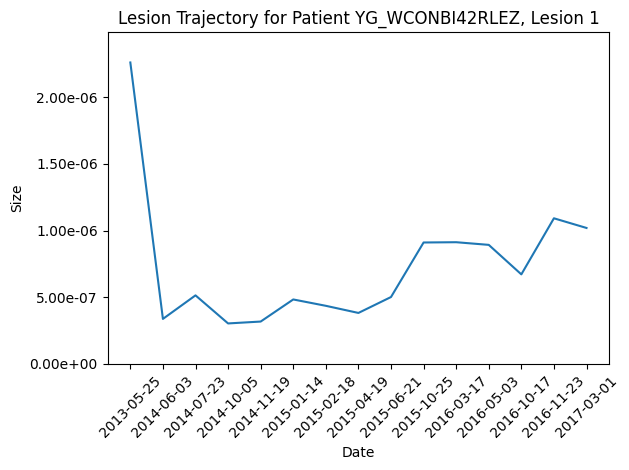

In [4]:
mri_dataloader.cache_lesion_trajectories[0].plot_trajectory_sizes()

In [7]:
mri_dataloader.cache_lesion_trajectories[0].patient_id

'YG_WCONBI42RLEZ'

In [8]:
mri_dataloader.cache_lesion_trajectories[0].label_id

1

In [5]:
mri_dataloader.cache_lesion_trajectories[0].plot_animation()

In [ ]:
# Diagnose YG_NRSFSRTTONBY trajectory 1
import numpy as np
patient = Patient('YG_NRSFSRTTONBY')
md = MRI_Dataloader()

trj = md.find_lesion_trajectory('YG_NRSFSRTTONBY', 1)
print(f"Trajectory 1 for {patient.patient_id}:")
print(f"  Dates: {trj.dates}")
print(f"  Number of frames stored: {len(trj.dates)}")

# Load and check each frame
print("\nChecking frame contents:")
data_all = trj.load_labels_for_inr(skip_empty=False)  # Load ALL, even empty ones
print(f"Loaded {len(data_all)} frames (with skip_empty=False)")

for i, (data_seg, time_pt) in enumerate(data_all):
    non_zero = np.count_nonzero(data_seg)
    frame_date = trj.dates[i] if i < len(trj.dates) else "?"
    status = "EMPTY ❌" if non_zero == 0 else f"OK ✓ ({non_zero} voxels)"
    print(f"  Frame {i:2d} ({frame_date}): {status}")


In [ ]:
# Clean up old trajectory files and regenerate
import os
import glob
from mri_dataloader import Patient

patient_id = 'YG_NRSFSRTTONBY'
patient = Patient(patient_id)

# Remove old trajectory .npz files
md = MRI_Dataloader()
pattern = os.path.join(md.data_prediction_path, patient_id, "lesion_trajectories_*.npz")
old_files = glob.glob(pattern)
print(f"Found {len(old_files)} old trajectory files")
for f in old_files:
    os.remove(f)
    print(f"  Deleted: {f}")

# Re-run trajectory building with the updated empty-frame filtering
print(f"\nRebuilding trajectories for {patient_id}...")
patient.merge_lesion_to_trajectory(
    max_gap=2,
    spatial_threshold=150,
    size_ratio_threshold=3.0,
    distance_threshold=100
)

print("\nDone! Trajectories have been regenerated with empty-frame filtering.")


In [5]:
import mlflow


mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Lesion_INR_Training")


run_id = "8fe747bb5b064f70be27b66dcb418617"
model_uri = f"runs:/{run_id}/lesion_inr_model"
model = mlflow.pytorch.load_model(model_uri)


In [6]:
model

LesionINR(
  (latent_vectors): Embedding(19700, 64)
  (latent_adapt): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (first_layer): SirenLayer(
    (linear): Linear(in_features=4, out_features=2048, bias=True)
    (conditioning_lin): Linear(in_features=64, out_features=4096, bias=True)
  )
  (layers): ModuleList(
    (0-7): 8 x SirenLayer(
      (linear): Linear(in_features=2048, out_features=2048, bias=True)
      (conditioning_lin): Linear(in_features=64, out_features=4096, bias=True)
    )
  )
  (final_layer): Linear(in_features=2048, out_features=1, bias=True)
)

In [14]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.0391,  0.0455, -0.0854,  ...,  0.0759,  0.0508, -0.0556],
         [-0.1337,  0.0962,  0.1110,  ..., -0.2439, -0.0483,  0.1157],
         [-0.1609,  0.2954,  0.2827,  ...,  0.0317, -0.0596, -0.0072],
         ...,
         [-0.1641,  0.0720,  0.1859,  ...,  0.0774,  0.0225,  0.0252],
         [-0.0563,  0.1476, -0.1643,  ...,  0.0082, -0.0851,  0.0335],
         [-0.2348,  0.3320, -0.1266,  ..., -0.0274,  0.0270, -0.1391]],
        device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([[-0.0581,  0.0642,  0.1197,  ..., -0.0570, -0.0949, -0.0642],
         [-0.1009, -0.0859, -0.0220,  ..., -0.0324, -0.1028,  0.0894],
         [ 0.0437,  0.1187,  0.1070,  ...,  0.0316,  0.0791,  0.0463],
         ...,
         [ 0.0151,  0.0488, -0.0191,  ..., -0.0298,  0.0418,  0.1005],
         [ 0.1036, -0.0898,  0.0877,  ...,  0.0239,  0.1181, -0.0611],
         [-0.0585,  0.0384, -0.0869,  ...,  0.0398,  0.0960, -0.0010]],
        device='cuda:0', r

## New lesion tracking

In [64]:
from mri_dataloader import MRI_Dataloader, Patient

In [65]:
patient = Patient('YG_WCONBI42RLEZ')
mri_dataloader = MRI_Dataloader()

In [66]:
patient.merge_lesion_to_trajectory(
    max_gap=15,                    # Skip up to 2 scans if needed
    spatial_threshold=100,         # Search radius for gap-filling
    size_ratio_threshold=15.0,     # Allow 4x size change across gaps
    distance_threshold=100         # Distance for consecutive scans
)

Extracting lesion data from 15 scans...
  Scan 0 (2013-05-25): 4 lesions
  Scan 1 (2014-06-03): 4 lesions
  Scan 2 (2014-07-23): 3 lesions
  Scan 3 (2014-10-05): 3 lesions
  Scan 4 (2014-11-19): 2 lesions
  Scan 5 (2015-01-14): 3 lesions
  Scan 6 (2015-02-18): 4 lesions
  Scan 7 (2015-04-19): 5 lesions
  Scan 8 (2015-06-21): 4 lesions
  Scan 9 (2015-10-25): 5 lesions
  Scan 10 (2016-03-17): 11 lesions
  Scan 11 (2016-05-03): 7 lesions
  Scan 12 (2016-10-17): 2 lesions
  Scan 13 (2016-11-23): 3 lesions
  Scan 14 (2017-03-01): 4 lesions

Lesion counts per scan: [4, 4, 3, 3, 2, 3, 4, 5, 4, 5, 11, 7, 2, 3, 4]

Matching lesions between consecutive scans...
  Scan 0 -> 1: 0/4 matches (4 unmatched from previous)
  Scan 1 -> 2: 3/4 matches (1 unmatched from previous)
  Scan 2 -> 3: 3/3 matches (0 unmatched from previous)
  Scan 3 -> 4: 0/3 matches (3 unmatched from previous)
  Scan 4 -> 5: 0/2 matches (2 unmatched from previous)
  Scan 5 -> 6: 2/3 matches (1 unmatched from previous)
  Scan 6 -

In [88]:
trj = mri_dataloader.find_lesion_trajectory('YG_WCONBI42RLEZ', 1)


In [89]:
trj.dates

['2013-05-25',
 '2014-06-03',
 '2014-07-23',
 '2014-10-05',
 '2014-11-19',
 '2015-01-14',
 '2015-02-18',
 '2015-04-19',
 '2015-06-21',
 '2015-10-25',
 '2016-03-17',
 '2016-05-03',
 '2016-10-17',
 '2016-11-23',
 '2017-03-01']

In [90]:
trj.plot_animation()

In [98]:
trj = mri_dataloader.find_lesion_trajectory('YG_WR00O2JLYFRJ', 1)
trj.plot_animation()


In [ ]:
patient = Patient('YG_X3IRQXCZALNB')
patient.merge_lesion_to_trajectory(max_gap=15,spatial_threshold=100,size_ratio_threshold=15.0, distance_threshold=100)

Extracting lesion data from 6 scans...
  Scan 0 (2016-07-02): 1 lesions
  Scan 1 (2016-07-05): 0 lesions
  Scan 2 (2016-08-20): 2 lesions
  Scan 3 (2016-11-20): 0 lesions
  Scan 4 (2018-07-03): 1 lesions
  Scan 5 (2018-10-20): 2 lesions

Lesion counts per scan: [1, 0, 2, 0, 1, 2]

Matching lesions between consecutive scans...
  Scan 0 -> 1: 0/1 matches (1 unmatched from previous)
  Scan 1 -> 2: 0/0 matches (0 unmatched from previous)
  Scan 2 -> 3: 0/2 matches (2 unmatched from previous)
  Scan 3 -> 4: 0/0 matches (0 unmatched from previous)
  Scan 4 -> 5: 0/1 matches (1 unmatched from previous)

Building trajectories from match chains...
Found 1 lesion trajectories
  - 1 trajectories have gaps (missing timepoints)
  - 0 trajectories span all timepoints

Saving relabeled masks...
Trajectory building complete!


## steady increase

In [1]:
from mri_dataloader import MRI_Dataloader, Patient

In [2]:
md = MRI_Dataloader()

In [5]:
md.cache_lesion_trajectories_from_n_scans(n_scans=6, only_growing=True)

Derivative threshold for growth detection: 0.3076
Derivative threshold for growth detection: 0.2012
Derivative threshold for growth detection: 0.1657
Derivative threshold for growth detection: 0.5906
Derivative threshold for growth detection: 0.0825
Derivative threshold for growth detection: 0.1632
Derivative threshold for growth detection: 0.2201
Derivative threshold for growth detection: 0.0016
Derivative threshold for growth detection: 0.0079
Derivative threshold for growth detection: 0.1865
Derivative threshold for growth detection: 0.3490
Derivative threshold for growth detection: 0.1750
Derivative threshold for growth detection: 0.2425
Derivative threshold for growth detection: 0.3675
Derivative threshold for growth detection: 0.0561
Derivative threshold for growth detection: 0.3389
Derivative threshold for growth detection: 0.1507
Derivative threshold for growth detection: 0.4378
Derivative threshold for growth detection: 0.3271
Derivative threshold for growth detection: 0.0274


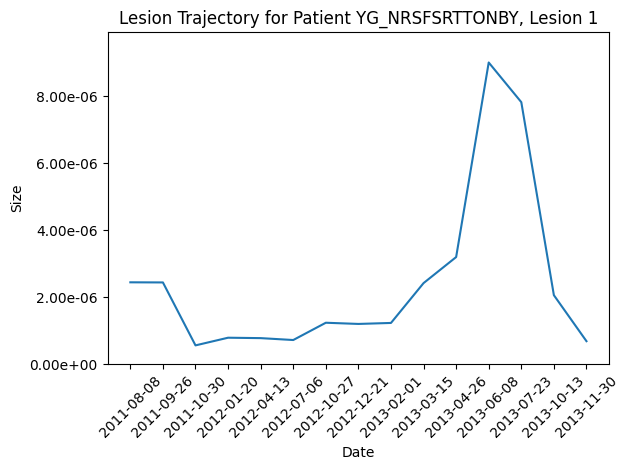

In [21]:
md.find_lesion_trajectory('YG_NRSFSRTTONBY', 1).plot_trajectory_sizes()

In [42]:
import numpy as np
sizes = md.find_lesion_trajectory('YG_NRSFSRTTONBY', 1).sizes

In [43]:
sizes

array([-12.92207093, -12.92358561, -14.3978408 , -14.05390382,
       -14.0696741 , -14.14560346, -13.60412149, -13.6334872 ,
       -13.60912341, -12.93170287, -12.65299024, -11.61684043,
       -11.75792075, -13.09334268, -14.19481239])

In [44]:
(sizes[1:] / sizes[:-1]) > 0.95

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True])

In [ ]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.ndimage import maximum_filter

def extract_growth_phase(sizes, smoothing_window=5, min_start_idx=1):
    """
    Extract the main growth phase of a lesion trajectory, ignoring early peaks.
    
    Args:
        sizes: array of lesion sizes (can be log-scale)
        dates: optional dates for reference
        smoothing_window: window size for Savitzky-Golay filter
        min_start_idx: minimum index to consider as peak (avoids very early spikes)
        
    Returns:
        start_idx, end_idx, plot_data
    """
    sizes_array = np.array(sizes)
    n = len(sizes_array)
    
    # Smooth the signal
    if n > smoothing_window:
        smoothed = savgol_filter(sizes_array, smoothing_window, 2)
    else:
        smoothed = sizes_array
    
    # Compute first derivative (growth rate)
    derivative = np.gradient(smoothed)
    
    # Find peak, but ignore very early peaks (skip first few points)
    valid_range_start = min(min_start_idx, n - 2)
    peak_idx = valid_range_start + np.argmax(smoothed[valid_range_start:])
    
    threshold = np.std(derivative) * 0.5
    print(f"Derivative threshold for growth detection: {threshold:.4f}")
    
    # Find growth start: first index where derivative becomes significantly positive
    growth_start_candidates = np.where(derivative[:peak_idx] > threshold)[0]
    if len(growth_start_candidates) > 0:
        start_idx = growth_start_candidates[0]
    else:
        start_idx = max(0, peak_idx - 3)
    
    # Find growth end: first index after peak where derivative becomes negative
    growth_end_candidates = np.where(derivative[peak_idx:] < -threshold)[0]
    if len(growth_end_candidates) > 0:
        end_idx = peak_idx + growth_end_candidates[0]
    else:
        end_idx = min(n - 1, peak_idx + 1)
    
    # Optimize start_idx: search in window around initial start_idx for lowest value
    start_idx = max(0, min(start_idx, n - 1))
    search_start_left = max(0, start_idx - 5)
    search_start_right = min(n - 1, start_idx + 5)
    
    best_start = start_idx
    best_start_value = sizes_array[start_idx]
    
    for idx in range(search_start_left, search_start_right + 1):
        if sizes_array[idx] < best_start_value:
            best_start = idx
            best_start_value = sizes_array[idx]
    
    start_idx = best_start
    
    # Optimize end_idx: search in window around initial end_idx for highest value
    end_idx = max(0, min(end_idx, n - 1))
    search_end_left = max(0, end_idx - 5)
    search_end_right = min(n - 1, end_idx + 5)
    
    best_end = end_idx
    best_end_value = sizes_array[end_idx]
    
    for idx in range(search_end_left, search_end_right + 1):
        if sizes_array[idx] > best_end_value:
            best_end = idx
            best_end_value = sizes_array[idx]
    
    end_idx = best_end
    
    # Ensure start_idx is always before end_idx
    if start_idx >= end_idx:
        start_idx = max(0, end_idx - 1)
    
    # After enforcing start < end, further optimize:
    # Descend the start: search backwards from start_idx for lower values
    # Allow up to 5% increase before stopping
    for idx in range(start_idx - 1, max(-1, start_idx - 10), -1):
        if idx >= 0 and idx < end_idx:
            # Allow the value to be up to 5% higher than start_idx
            if sizes_array[idx] <= sizes_array[start_idx] + np.log(1.05):
                start_idx = idx
            else:
                break
    
    # Ascend the end: search forwards from end_idx for higher values
    # Allow up to 5% decrease before stopping
    for idx in range(end_idx + 1, min(n, end_idx + 10)):
        if idx > start_idx:
            # Allow the value to be up to 5% lower than end_idx
            if sizes_array[idx] >= sizes_array[end_idx] + np.log(0.95):
                end_idx = idx
            else:
                break


    return start_idx, end_idx, {'smoothed': smoothed, 'derivative': derivative, 'peak': peak_idx}

In [215]:
sizes = md.find_lesion_trajectory('YG_NRSFSRTTONBY', 1).sizes
# sizes = md.find_lesion_trajectory('YG_WCONBI42RLEZ', 2).sizes
# sizes = md.find_lesion_trajectory('YG_ZZECURU4NBRG', 5).sizes
a = extract_growth_phase(sizes)

Derivative threshold for growth detection: 0.3138


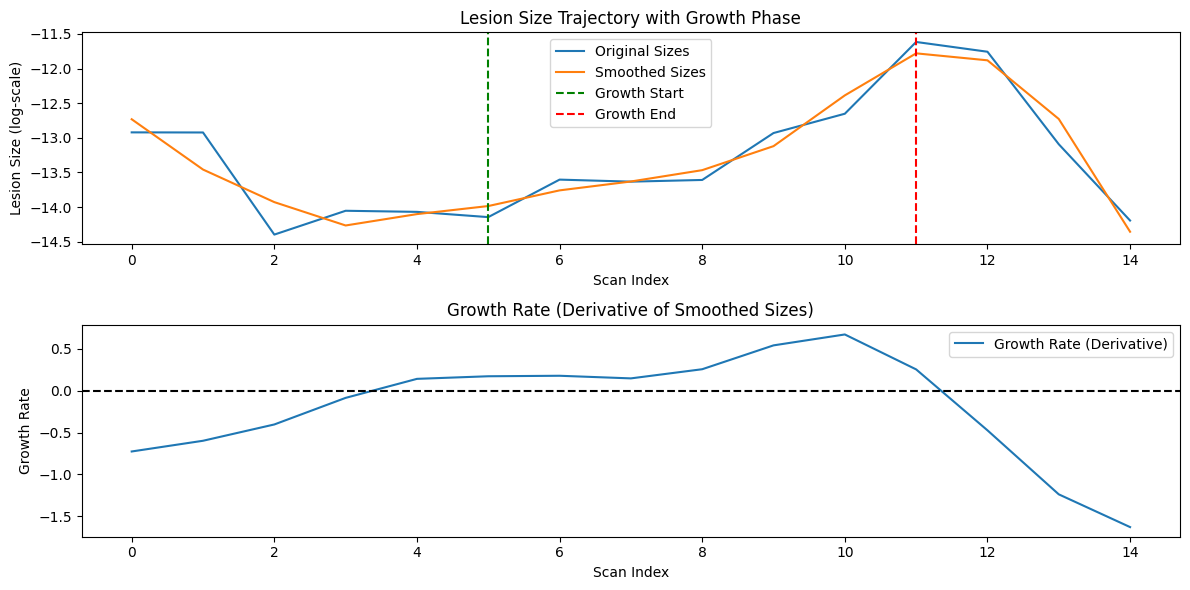

In [216]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(sizes, label='Original Sizes')
plt.plot(a[2]['smoothed'], label='Smoothed Sizes')
plt.axvline(a[0], color='g', linestyle='--', label='Growth Start')
plt.axvline(a[1], color='r', linestyle='--', label='Growth End')
plt.legend()
plt.title('Lesion Size Trajectory with Growth Phase')
plt.xlabel('Scan Index')
plt.ylabel('Lesion Size (log-scale)')
plt.subplot(2, 1, 2)
plt.plot(a[2]['derivative'], label='Growth Rate (Derivative)')
plt.axhline(0, color='k', linestyle='--')
plt.legend()
plt.title('Growth Rate (Derivative of Smoothed Sizes)')
plt.xlabel('Scan Index')
plt.ylabel('Growth Rate')
plt.tight_layout()
plt.show()

## Version 2.0

In [1]:
import os
os.chdir('/home/benjaminb/Dokumente/JKU/Semester_9/Practical_Work')
from utils.mri_dataloader import MRI_Dataloader

mdl = MRI_Dataloader()


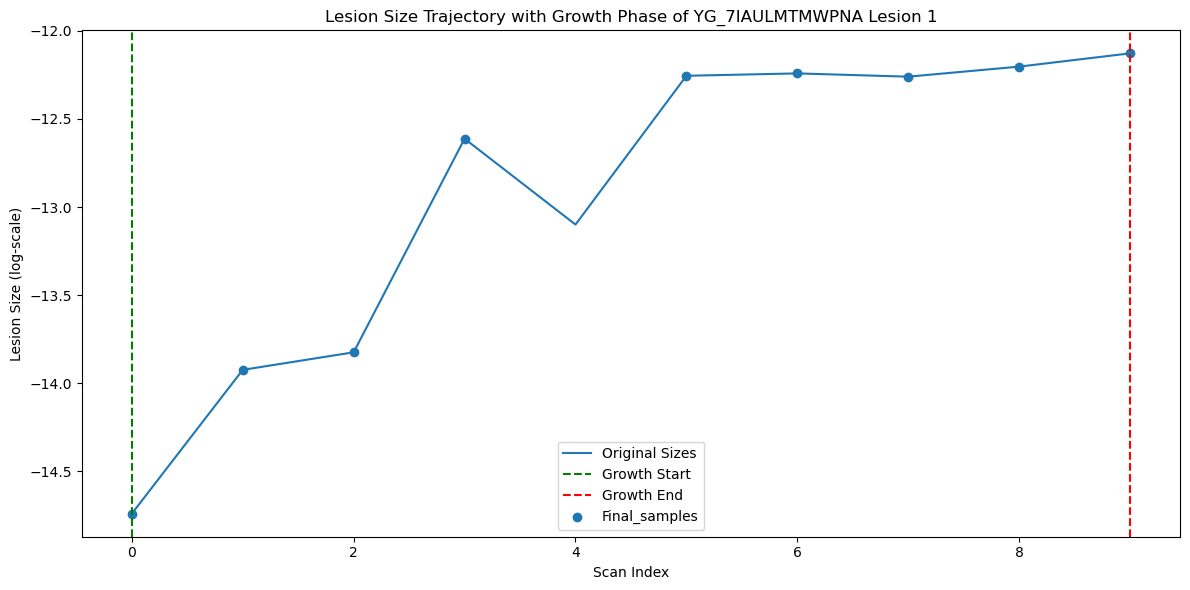

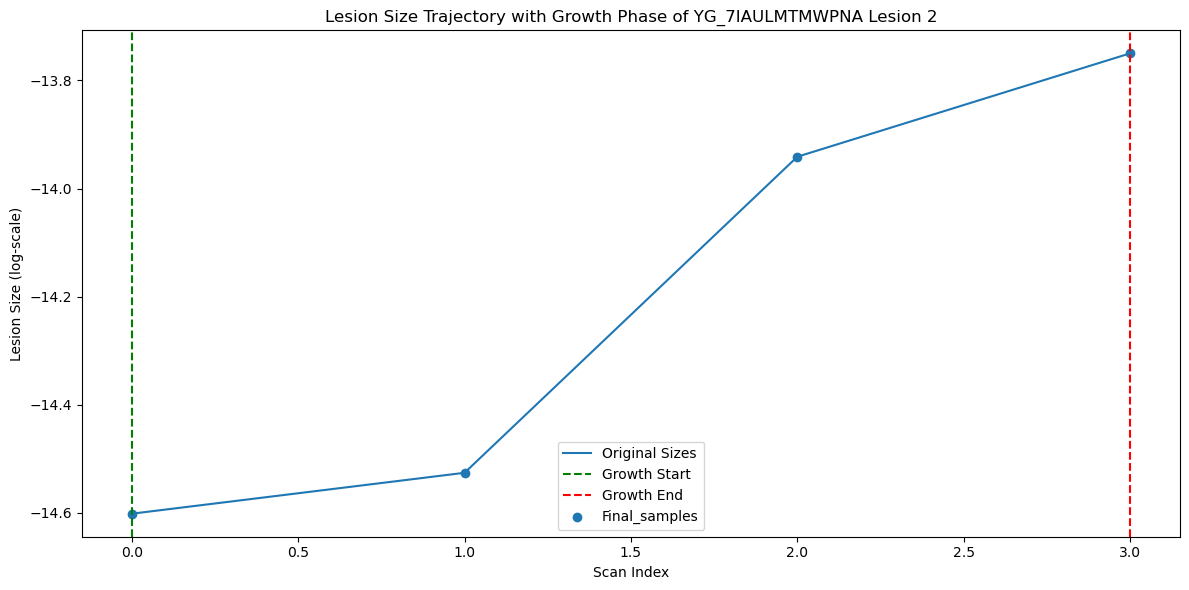

Lesion trajectory file not found at data/entire_yale_dataset/predictions/YG_7IAULMTMWPNA/lesion_trajectories_3.npz. Cannot load trajectory.


AttributeError: 'NoneType' object has no attribute 'plot_growth_phase'

In [8]:
for i in range(1,10):
    mdl.find_lesion_trajectory("YG_7IAULMTMWPNA", i).plot_growth_phase()

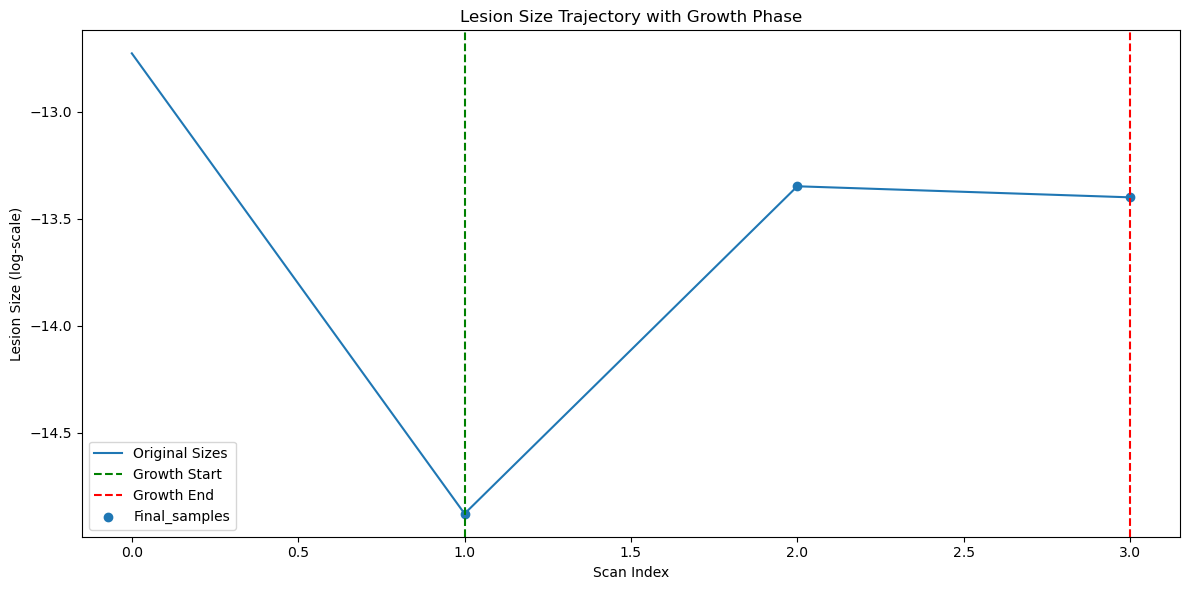

In [4]:
mdl.find_lesion_trajectory("YG_0JCOFA4MZFB4", 2).plot_growth_phase()

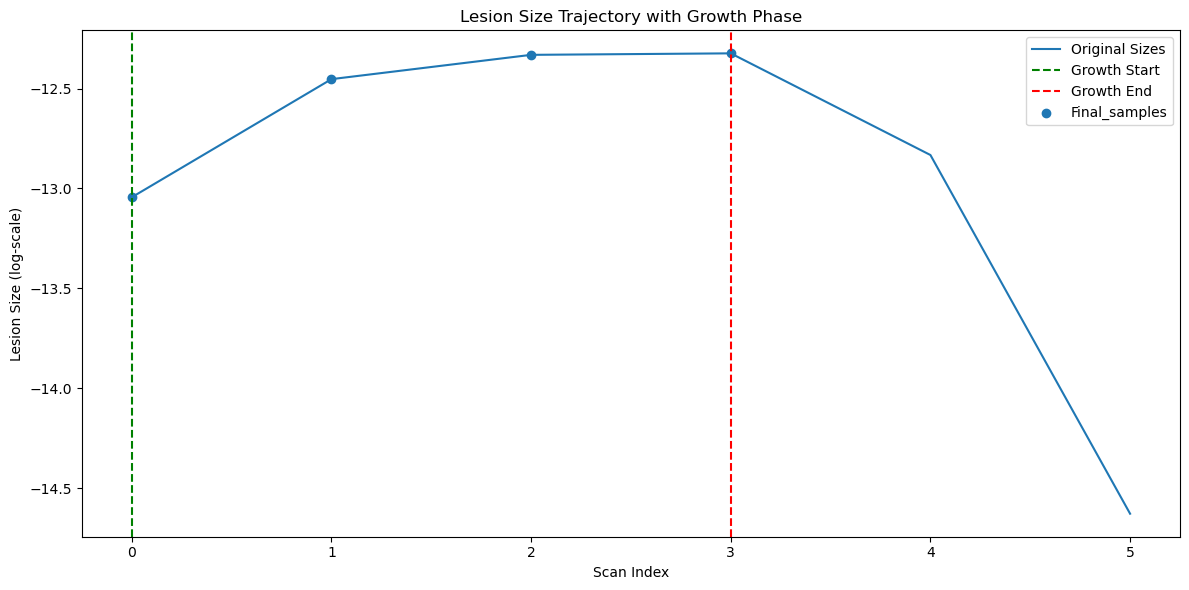

In [5]:
mdl.find_lesion_trajectory("YG_0JCOFA4MZFB4", 3).plot_growth_phase()

In [7]:
mdl.cache_lesion_trajectories_from_n_scans(n_scans=4, only_growing=True)

Found 2 trajectories with at least 4 scans.
